In [40]:

pip install --upgrade opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 841.8 kB/s eta 0:00:001m751.6 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 1.7 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 1.3 MB/s eta 0:00:00m eta 0:00:010:00:01m
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.0
    Uninstalling numpy-1.26.0:
      Successfully uninstalled numpy-1.26.0
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.11.0.86
    Uninstalling opencv-python-4.11.0.86:
      Successfully uninstalled opencv-python-4.11.0.86
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import cvlib as cv
from cvlib.object_detection import draw_bbox

In [5]:
impath = r'Data/GroundtruthSeq/RawImages'
imNames = sorted(os.listdir(impath))

for imName in imNames:
    frame = cv2.imread(os.path.join(impath,imName))
    if frame is None:
        print(f"Could not load image: {imName}")
        continue
    frame = cv2.resize(frame,dsize=(600,400))
    cv2.imshow('Display',frame)
    k=cv2.waitKey(10)& 0xff
    if k==27:
        break
cv2.destroyAllWindows()


Could not load image: .ipynb_checkpoints


In [6]:
videopath = 'Data/sroom4.avi'
cap = cv2.VideoCapture(videopath)
while(1):
    ret, frame = cap.read()
    frame = cv2.resize(frame,dsize=(600,400))
    cv2.imshow('Display',frame)
    k = cv2.waitKey(30) & 0xff
    if k==27:
        break
cap.release()
cv2.destroyAllWindows()

In [6]:
B = cv2.imread( r'Data/GroundtruthSeq/RawImages/seq00.avi0001.bmp')
I = cv2.imread( r'Data/GroundtruthSeq/RawImages/seq00.avi0350.bmp')

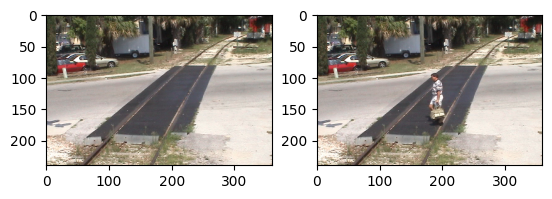

In [7]:
plt.subplot(1,2,1)
plt.imshow(B[:,:,::-1])
plt.subplot(1,2,2)
plt.imshow(I[:,:,::-1])
plt.show()

In [8]:
b = np.float32(B)
i = np.float32(I)

In [9]:
c = (i-b)**2

In [10]:
c2 = np.sum(c,axis=2)

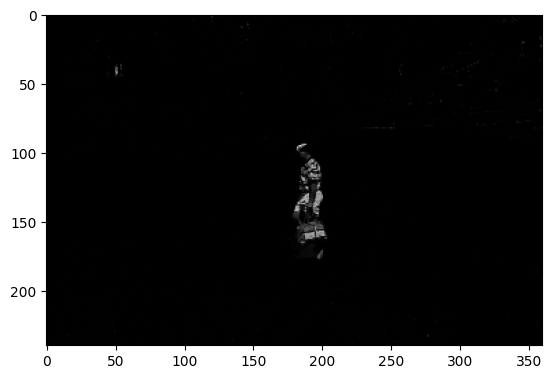

In [11]:
plt.imshow(c2, cmap='grey')

### foreground model

In [10]:
impath = r'Data/GroundtruthSeq/RawImages'
imNames = sorted(os.listdir(impath))

fgModel = cv2.createBackgroundSubtractorMOG2()

for imName in imNames:
    frame = cv2.imread(os.path.join(impath,imName))
    if frame is None:
        print(f"Could not load image: {imName}")
        continue
    frame = cv2.resize(frame,dsize=(600,400))
    fgmask = fgModel.apply(frame)
    F = np.zeros(frame.shape,np.uint8)
    F[:,:,0],F[:,:,1],F[:,:,2] = fgmask,fgmask,fgmask
    F2 = np.hstack((frame,F))
    cv2.imshow('Display',F2)
    k=cv2.waitKey(30)& 0xff
    if k==27:
        break
cv2.destroyAllWindows()


Could not load image: .ipynb_checkpoints


In [7]:
def f_keepLargeComponents(I,th):
    R = np.zeros(I.shape)<0
    unique_labels = np.unique(I.flatten())
    for label in unique_labels:
        if label ==0:
            pass
        else:
            I2= I==label
            if np.sum(I2)>th:
                R = R|I2
    return np.float32(255*R)

In [8]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf

def f_saveSeq(C, counter,th,outputPath):
    if len(C)<th:
        pass
    else:
        k =1
        for frame in C:
            imName = str(counter)+'_'+str(k)+'.jpg'
            finalpath = os.path.join(outputPath,imName)
            bbox, labels, conf = cv.detect_common_objects(frame)
            frame = draw_bbox(frame,bbox,labels,conf)
            cv2.imwrite(finalpath,frame)
            k+=1

In [9]:
def f_displayseq(output_path):
    impath = output_path
    imNames = sorted(os.listdir(impath))
    
    for imName in imNames:
        frame = cv2.imread(os.path.join(impath,imName))
        if frame is None:
            print(f"Could not load image: {imName}")
            continue
        frame = cv2.resize(frame,dsize=(600,400))
        cv2.imshow('Display',frame)
        k=cv2.waitKey(10)& 0xff
        if k==27:
            break
    cv2.destroyAllWindows()
        

In [16]:
impath = r'Data/GroundtruthSeq/RawImages'
imNames = sorted(os.listdir(impath))

fgModel = cv2.createBackgroundSubtractorMOG2()
leastNumoffframes = 5
idx = []
C = [ ]
counter = 0

outputPath = r'out'

for imName in imNames:
    frame = cv2.imread(os.path.join(impath,imName))
    if frame is None:
        print(f"Could not load image: {imName}")
        continue
    frame = cv2.resize(frame,dsize=(600,400))
    fgmask = fgModel.apply(frame)
    K_r = cv2.getStructuringElement(cv2.MORPH_RECT,(3,3))
    fgmask = cv2.morphologyEx(np.float32(fgmask),cv2.MORPH_OPEN,K_r)
    num_labels, labels_im = cv2.connectedComponents(np.array(fgmask>0,np.uint8))
    fgmask = f_keepLargeComponents(labels_im,1000)
    if np.sum(fgmask)>0:
        idx.append(counter)
        C.append(frame)
    if len(idx)>= 2 and idx[-1] > idx[-2]+1:
        f_saveSeq(C,counter,leastNumoffframes,outputPath)
        idx=[]
        C=[]
    F = np.zeros(frame.shape,np.uint8)
    F[:,:,0],F[:,:,1],F[:,:,2] = fgmask,fgmask,fgmask
    F2 = np.hstack((frame,F))
    cv2.imshow('Display',F2)
    k=cv2.waitKey(10)& 0xff
    if k==27:
        break
f_saveSeq(C,counter,leastNumoffframes,outputPath)
cv2.destroyAllWindows()


Could not load image: .ipynb_checkpoints


In [16]:
f_displayseq(r'out')

Could not load image: .ipynb_checkpoints


In [17]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf

error: OpenCV(4.12.0) /io/opencv/modules/dnn/src/dnn_read.cpp:58: error: (-2:Unspecified error) Cannot determine an origin framework of files: path_to_your_weights, path_to_this_cfg_file in function 'readNet'


In [14]:
import cv2
net = cv2.dnn.readNet(
    "/home/arunkumar/virtual-env/my-jupytrt-env/lib/python3.12/site-packages/cvlib/yolo/yolov4.weights",
    "/home/arunkumar/virtual-env/my-jupytrt-env/lib/python3.12/site-packages/cvlib/yolo/yolov4.cfg"
)
